# Multi-Class Convolutional Neural Network
This notebook shows the code i made for a CNN using the MNIST Chinese character dataset, where our goal is to make a model that can accurately predict the type of handwritten character that is in an image

## Overview
I used OpenCV to process the images into matrices that can be fed into a model, and I'm using PyTorch for the neural network. Im using Adam optimizer and Cross Entropy Loss, the total amount of classes are 15, which correspond to the characters:
- 零 = 0
- 一 = 1 
- 二 = 2 
- 三 = 3
- 四 = 4 
- 五 = 5 
- 六 = 6 
- 七 = 7 
- 八 = 8
- 九 = 9 
- 十 = 10 
- 百 = 100 
- 千 = 1,000 
- 万 = 10,000 
- 亿 = 100,000,000

This dataset is pretty balanced and has a total of 15,000 images (1k for each character)

In [47]:
#imports :p
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import os

# Image Preprocessing
The first step is to turn these regular jpg images into something that we can actually feed into a model. I am using OpenCV for this, but the first step is to get the path where all the images are stored in my computer, that way we can actually access them :p

In [48]:
#path i used to store the images from the mnist dataset
imgs_path = 'Records/data/data'

## OpenCV Stuff
And now OpenCV can be used, first I define a list that substitutes the characters for nums that we can use as classes in the model.

Then, we go through every image, determine which class it belongs to, then store the image as an array in the list X, and the corresponding class it belongs to in y, both sharing the same index in both lists

In [49]:
'''
these classes are equivalent to ['零', '一', '二', '三', '四', '五', '六','七', '八','九', '十', '百', '千', '万', '亿'] 
    in terms of classification
'''
classes = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]

'''
Using opencv to get a list of X values (img array) and y values (corresponding class)
    - This mnist dataset orders images from 1-15, where each chinese character corresponds to one of these numbers
'''
X = []
y = []
for img in os.listdir(imgs_path):
    img_array = cv.imread(os.path.join(imgs_path,img),cv.IMREAD_GRAYSCALE)
    if '_' in img[-6:-4]:
        i = int(img[-5]) - 1
    else: 
        i = int(img[-6:-4])-1
    X.append(img_array)
    y.append(classes[i])

## Visualizing the images
Here, I made a plot to show sample images for each class, to make it easier to see which character belongs to what class

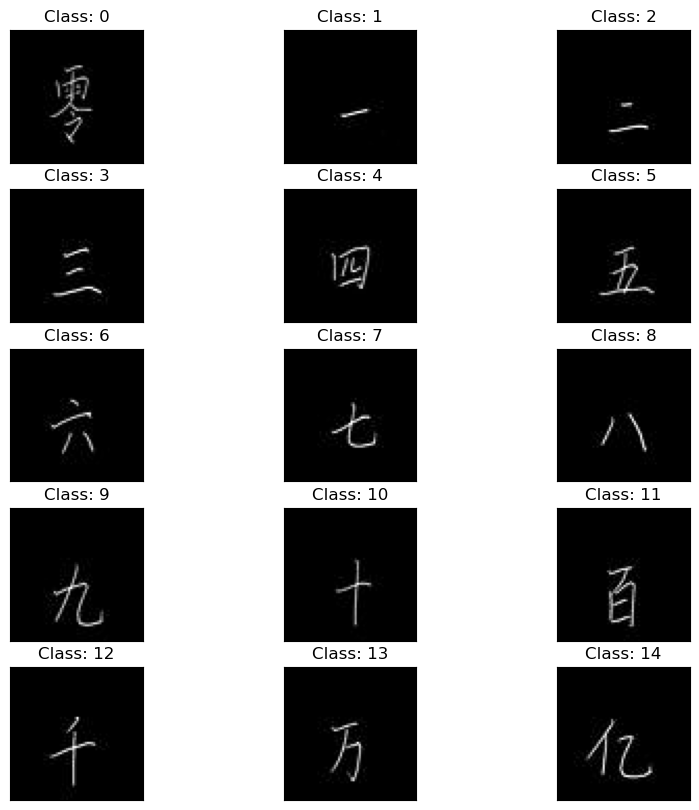

In [50]:
'''
sample output:
    here we can see the way imgs are ordered, where the final num in 1_1_**1** is what we look at to determine what class it belongs to
'''
fig, ax = plt.subplots(5,3,figsize=(10,10))
j = 0
k = 0
for i in range (15):
    img = f"Records/data/data/input_1_1_{i+1}.jpg"
    img_array = cv.imread(img,cv.IMREAD_GRAYSCALE)
    ax[k][j].imshow(img_array,cmap='gray')
    ax[k][j].set_title(f"Class: {i}")
    ax[k][j].set_xticks([])
    ax[k][j].set_yticks([])
    j+= 1
    if j >2: 
        k += 1
        j = 0

## Splitting the Data
Here, I turn the arrays into numpy arrays and then use sklearns test_train_split() function to split the image data into a training set which contains 80% of the data, and a testing set which contains 20% of the data. This is so that I can train the model with the training set (getting as much training data as I can get), while still having a good chunk of images that the model has never seen to use to train test how well the model will actually work against data it has never seen before

I also normalize the values in the arrays so that the image values (usually go from 0-255) can be represented in the range between [0,1]

In [51]:
#turn them into np arrays and get a 80/20 test-train-split
X = np.array(X)
y = np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [52]:
#normalize values to be between 0 and 1
X_train = X_train/255
X_test = X_test/255

## More Preprocessing
Here I am turning these np arrays into tensor arrays, as well as making sure that the X arrays only have 1 channel representing grayscale, and since I am using Apple Silicon for GPU acceleration, I am converting the vars in the matrices into numbers that MPS supports 

From there I use PyTorch's TensorDataset and DataLoader modules to make a dataset that I can then load onto DataLoader so that I can feed images into the model in batches instead of the whole training dataset all at once each epoch

In [53]:
#im using Apple Silicon for GPU acceleration, and MPS doesn't take 64 bit floats :p
#Since color doesn't matter here, im ensuring there is only one channel (grayscale)
X_train_t = torch.from_numpy(X_train).to(torch.float32).unsqueeze(1)
X_test_t = torch.from_numpy(X_test).to(torch.float32).unsqueeze(1)

y_train_t = torch.from_numpy(y_train).long()
y_test_t = torch.from_numpy(y_test).long()

In [54]:
#make dataset from these tensors linking X and y values so we can later load them into DataLoader() for batch sampling
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t,y_test_t)

In [55]:
#Using DataLoader so we can feed the images in batches into the model
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False
)

## Making the Model
Here I am making the actual model, which consists of 3 convolutional layers and a final linear layer that give us the 15 class output where we can see which one of the classes the model believes the image is closest to

In [56]:
#here if you wanted to use this code change "mps" for your device (i.e. "cuda") or just use cpu (slower)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#three layers of convolution->activation->pooling then flatten tensor into a single vector into a linear layer for geting
#the final output
#convolution layer looks like: (batch_size, num_channels, img_height, img_width)
model = nn.Sequential(
    #takes in 1 input channel and will output 16 channels using a kernel size of 3x3 for the image 
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    #activation function
    nn.ReLU(),
    #downsamples feature maps from 64x64 to 32x32 by taking the strongest features in a 2x2 region of the img
    nn.MaxPool2d(2),

    #16 channels in, 32 out, same kernel size of 3x3
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    #activation func
    nn.ReLU(),
    #downsamples from 32x32 to 16x16
    nn.MaxPool2d(2),

    #final convolutional layer going from 32 channels in to 64 out with a 3x3 kernel
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    #activation func
    nn.ReLU(),
    #downsamples from 16x16 to 8x8
    nn.MaxPool2d(2),

    #Each feature map is compressed to one number. output becomes (batch, 64, 1, 1)
    nn.AdaptiveAvgPool2d((1, 1)),
    #flattens the layer to a vector of just <64>
    nn.Flatten(),
    #linear function which gives out the output layer of 15, from which the model will choose and decide which class it thinks
    #the img belongs to 
    nn.Linear(64, 15)
).to(device) #use preffered method for GPU acceleration

## Training the Model
Here We actually train the model using the training data that we set aside earlier. The model will be fed the images in batches and will propagate each image through the model, give an output, calculate the loss, then backpropagate to tweak the model parameters based on the loss output.

After the model finishes going through all the epochs I made two plots which show the progress that the model made in increasing accuracy and decreasing loss

In [57]:
#setting the optimizer and loss funcs, in this case we're using Adam optimizer and Cross Entropy Loss
optimizer = Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

#30 epochs (iterations)
epochs = 30

#for plotting purposes
acc_over_time = []
loss_over_time = []

#run the model for the set amount of epochs that we want
for epoch in range(epochs):
    #forward propagation begin
    model.train()
    #var initializations
    running_loss = 0
    correct = 0
    total = 0
    #converting these into MPS vars
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        #resetting the gradients
        optimizer.zero_grad()

        #feeding images through the model to get the models outputs
        outputs = model(images)
        #comparing those outputs (predicted class) to the actual value (the actual class the img belongs to)
        loss = criterion(outputs, labels)
        # backpropagation after getting the loss
        loss.backward()
        #updates parameters based on gradient loss
        optimizer.step()

        #for output visualization
        preds = outputs.argmax(dim=1)
        running_loss += loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    #getting accuracy and loss for the epoch
    acc = correct / total * 100
    loss = running_loss / len(train_loader)
    #adding onto lists for plotting later
    acc_over_time.append(acc)
    loss_over_time.append(loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Acc: {acc:.2f}%")

Epoch 1/30, Loss: 2.6041, Acc: 11.34%
Epoch 2/30, Loss: 2.0141, Acc: 32.57%
Epoch 3/30, Loss: 1.5059, Acc: 50.07%
Epoch 4/30, Loss: 1.1644, Acc: 62.71%
Epoch 5/30, Loss: 0.9275, Acc: 70.93%
Epoch 6/30, Loss: 0.7718, Acc: 75.78%
Epoch 7/30, Loss: 0.6650, Acc: 78.99%
Epoch 8/30, Loss: 0.5910, Acc: 81.08%
Epoch 9/30, Loss: 0.5314, Acc: 82.92%
Epoch 10/30, Loss: 0.4874, Acc: 84.22%
Epoch 11/30, Loss: 0.4549, Acc: 85.23%
Epoch 12/30, Loss: 0.4177, Acc: 86.32%
Epoch 13/30, Loss: 0.3899, Acc: 87.42%
Epoch 14/30, Loss: 0.3693, Acc: 88.12%
Epoch 15/30, Loss: 0.3506, Acc: 88.88%
Epoch 16/30, Loss: 0.3248, Acc: 89.43%
Epoch 17/30, Loss: 0.3080, Acc: 89.85%
Epoch 18/30, Loss: 0.2870, Acc: 90.83%
Epoch 19/30, Loss: 0.2767, Acc: 90.88%
Epoch 20/30, Loss: 0.2641, Acc: 91.30%
Epoch 21/30, Loss: 0.2533, Acc: 92.00%
Epoch 22/30, Loss: 0.2385, Acc: 92.62%
Epoch 23/30, Loss: 0.2292, Acc: 92.79%
Epoch 24/30, Loss: 0.2148, Acc: 93.49%
Epoch 25/30, Loss: 0.2071, Acc: 93.60%
Epoch 26/30, Loss: 0.1993, Acc: 93

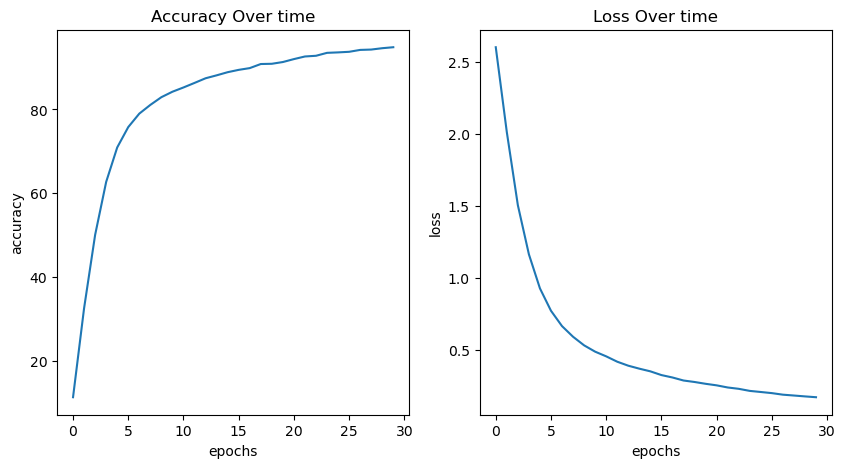

In [58]:
#plotting accuracy and loss over time
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(acc_over_time)
ax[0].set_title("Accuracy Over time")
ax[0].set_xlabel("epochs")
ax[0].set_ylabel("accuracy")
ax[1].plot(loss_over_time)
ax[1].set_title("Loss Over time")
ax[1].set_xlabel("epochs")
ax[1].set_ylabel("loss")
plt.show()

# Evaluating the Model
once the model is finished training we can test the model by feeding the model images it has never seen before and then taking the results to see how well the model does in classifying these new images

In [59]:
#evaluating the model
model.eval()
#for confusion matrix later
correct = 0
total = 0
y_pred= []
y_act = []

with torch.no_grad():
    #propagates new images to test the model on its accuracy
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        #for output visualization
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        y_pred.append(preds.to('cpu').detach().numpy())
        y_act.append(labels.to('cpu').detach().numpy())

acc = correct / total * 100
#printing basic model stats
print(f"Epoch {epoch+1}/{epochs}, \nLoss: {running_loss/len(train_loader):.4f}, \nTest Acc: {acc:.2f}%")

Epoch 30/30, 
Loss: 0.1708, 
Test Acc: 93.87%


## Confusion Matrix Results
We can take a look at all of the predictions the model made for each image and see how well the model did for each class, evaluating the performance of the model by comparing actual target values with predicted values.

In [60]:
#making one giant unbatched list
total_pred = []
count = 0
for i in range(len(y_pred)):
    for j in range(len(y_pred[i])-1):
        total_pred.append(int(y_pred[i][j]))
total_act = []
for i in range(len(y_act)):
    for j in range(len(y_act[i])-1) :
        total_act.append(int(y_act[i][j]))

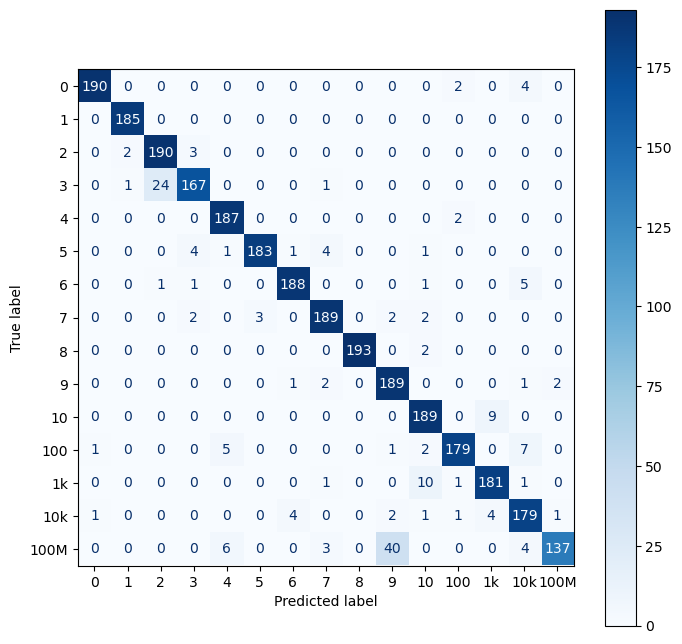

In [61]:
#making a confusion matrix from the test results
classes = ['0','1','2','3','4','5','6','7','8','9','10','100','1k','10k','100M']
confusion_matrix = metrics.confusion_matrix(total_act, total_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = classes)
cm_display.plot(cmap=plt.cm.Blues)
fig = plt.gcf().set_size_inches(8, 8)
plt.show()

## The End
And that is everything that I did for this small project. This project was something I made so that I can get back into CNN's since I had taken a little break and wanted to see what concepts I needed to work on the most!